# Importing all the libaries 

In [123]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import random_statevector
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Making the bell State in Q2 and Q3

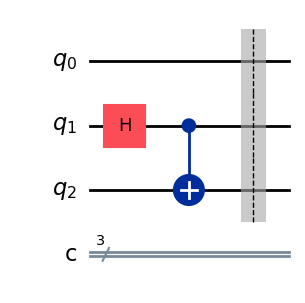

In [124]:
qc=QuantumCircuit(3,3)

qc.h(1)
qc.cx(1,2)
qc.barrier()
qc.draw("mpl")



# making a random 1 qubit state

Statevector([0.21424427+0.20485384j, 0.50936062-0.80788988j],
            dims=(2,))


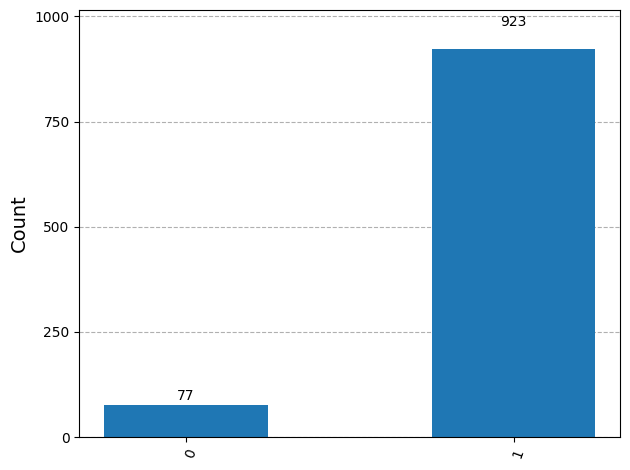

In [125]:
psi = random_statevector(2,seed=1)
qc.initialize(psi.data, 0)
psi.sample_counts(shots=1000)
print(psi)
qc.barrier()
plot_histogram(psi.sample_counts(shots=1000))



# the protocol

### Step 1
we perform a cnot with q1 being the target bit and a hadamard on q0

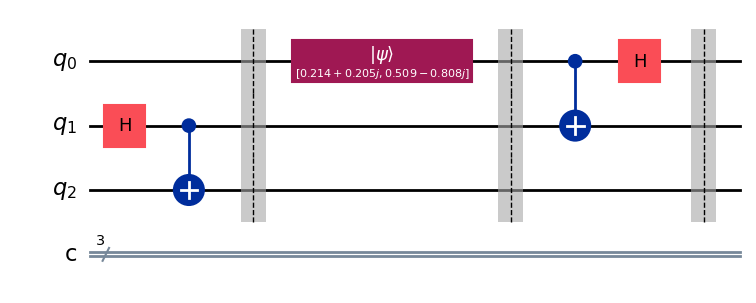

In [126]:
qc.cx(0,1)
qc.h(0)
qc.barrier()
qc.draw("mpl")

### Step 2
we measure both q0 and q1

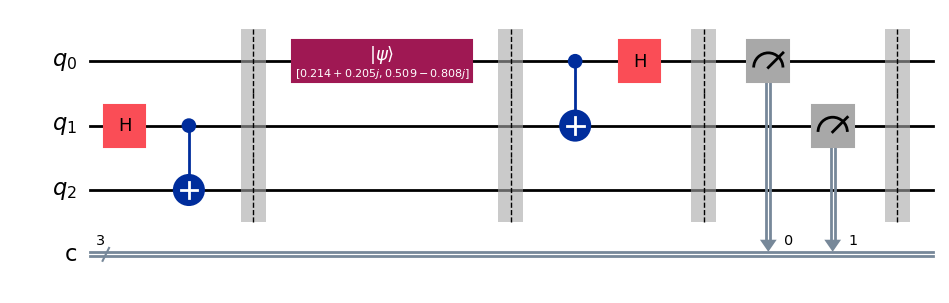

In [127]:
qc.measure(0,0)
qc.measure(1,1)
qc.barrier()
qc.draw("mpl")

### Step 3

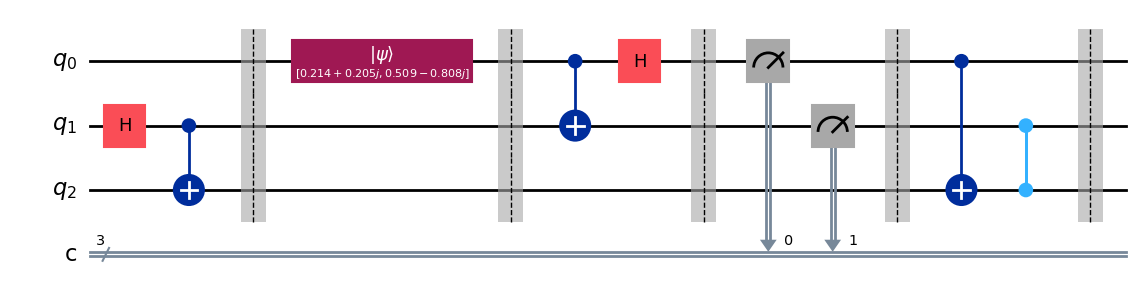

In [128]:
qc.cx(0,2)
qc.cz(1,2)
qc.barrier()
qc.draw("mpl")

### Step 4

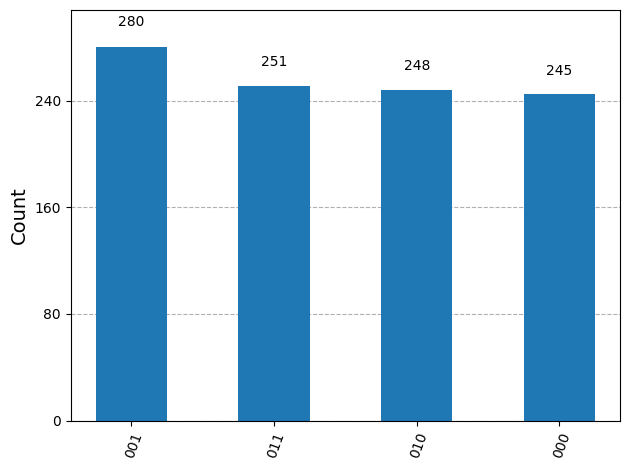

In [129]:
Backend = AerSimulator()
sampler = Sampler(mode=Backend)

job = sampler.run([qc], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()

plot_histogram(counts, sort='value_desc')